<p align="center">
  <a href="https://vicena.ai"><strong>Built with Vicena</strong></a>
</p>

# Sensitivity and constrained optimization

This notebook is part of the Vicena Research Twins collection. Purpose: rank parameter sensitivity and search heating and cooling setpoints for electricity cost subject to an occupied comfort-degree-hour limit. Inputs use the documented thermal, energy, tariff, and temperature units. Execution prints the selected candidate and whether the constraint is feasible. Maturity: Level 0 synthetic reference. Limitation: synthetic optimization is not guaranteed operational savings.

Best candidate: {'heating_setpoint_c': 18.0, 'cooling_setpoint_c': 23.0, 'energy_kwh': 235.90860410805922, 'cost': 37.68129061620888, 'comfort_degree_hours': 55.381854910553905, 'constraint_feasible': False}
Top sensitivity rows:
            parameter  fractional_change  energy_change_percent  comfort_change_degree_hours
          heating_cop                0.1              -6.606493                     0.000000
          ua_kw_per_k                0.1               4.807850                    15.327339
capacitance_kwh_per_k                0.1               2.357743                    -3.139392
        base_power_kw                0.1               2.176258                     0.000000
         fan_power_kw                0.1               0.556600                     0.000000


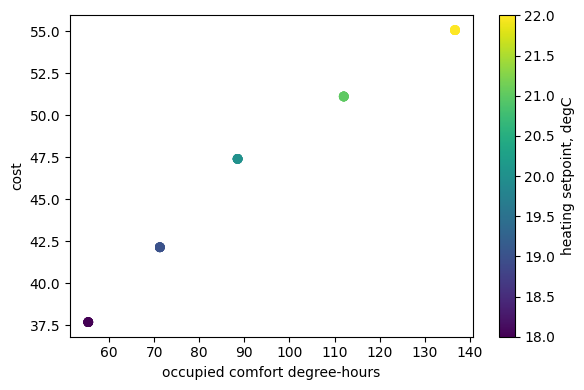

In [2]:
from building_hvac_twin.data import load_dataset, temporal_split
from building_hvac_twin.model import TwinParameters
from building_hvac_twin.analysis import calibrate,sensitivity,optimize_setpoints
import matplotlib.pyplot as plt

data=load_dataset('../datasets/example/building_timeseries.csv'); train,val=temporal_split(data)
p,_=calibrate(train,TwinParameters()); sens=sensitivity(val,p); best,candidates=optimize_setpoints(val,p,12)
print('Best candidate:',best); print('Top sensitivity rows:'); print(sens.head().to_string(index=False))
plt.figure(figsize=(6,4)); plt.scatter(candidates.comfort_degree_hours,candidates.cost,c=candidates.heating_setpoint_c); plt.xlabel('occupied comfort degree-hours'); plt.ylabel('cost'); plt.colorbar(label='heating setpoint, degC'); plt.tight_layout(); plt.show()